In [48]:
# import time
# from tqdm.notebook import tqdm
import os
os.environ["HDF5_USE_FILE_LOCKING"] = "FALSE"
from h5 import HDFArchive

from triqs.atom_diag import AtomDiagComplex
from triqs.operators import n, c, c_dag
from itertools import product
from triqs.plot.mpl_interface import oplot

from sort import sort_states_full
from three_pt_corr import *
from four_pt_corr import *
from four_pt_corr_v2 import FourPtCorr as FourPtCorr_v2

from itertools import product

In [49]:
# Number of bosonic Matsubara frequencies for susceptibility calculation
bn_iw = 10
# Number of fermionic Matsubara frequencies for susceptibility calculation
fn_iw = 10

beta = 2.0              # Inverse temperature

biw_mesh = MeshImFreq(beta = beta, statistic = 'Boson', n_iw = bn_iw)
fiw_mesh = MeshImFreq(beta = beta, statistic = 'Fermion', n_iw = fn_iw)

In [50]:
# Hubbard dimer

####################
# Input parameters #
####################

eps = [-1.9, -2.1]      # Energy levels of the atoms
t = 0.5                 # Hopping matrix element
U = 4.0                 # Coulomb repulsion
h_field = 0.05          # Magnetic field

spin_names = ("up", "dn")
atoms = (0, 1)

H = sum(e * n(s, a) for (a, e), s in product(zip(atoms, eps), spin_names))
H += sum(-h_field * (n('up', a) - n('dn', a)) for a in atoms)
H += U * sum(n('up', a) * n('dn', a) for a in atoms)
H += t * sum((c_dag(sp, 0) * c(sp, 1) + c_dag(sp, 1) * c(sp, 0)) for sp in spin_names)

fops = list(product(spin_names, atoms))

In [51]:
# # 2x2 Hubbard plaquette

# ####################
# # Input parameters #
# ####################

# eps = [-1.9, -2.1, -1.9, -2.1]  # On-site energies
# t = 0.5                 # Nearest-neighbor hopping
# U = 4.0                 # Coulomb repulsion
# h_field = 0.05          # Magnetic field

# spin_names = ("up", "dn")
# atoms = (0, 1, 2, 3)


# ####################
# # Hubbard Hamiltonian
# ####################

# # On-site energies
# H = sum(
#     e * n(s, a)
#     for (a, e), s in product(zip(atoms, eps), spin_names)
# )

# # Magnetic field
# H += sum(
#     -h_field * (n('up', a) - n('dn', a))
#     for a in atoms
# )

# # On-site Hubbard interaction
# H += U * sum(
#     n('up', a) * n('dn', a)
#     for a in atoms
# )

# # Nearest-neighbor hopping
# #
# #       0 ---- 1
# #       |      |
# #       |      |
# #       2 ---- 3
# #
# H += t * sum(
#     c_dag(sp, i) * c(sp, j)
#     + c_dag(sp, j) * c(sp, i)
#     for sp in spin_names
#     for i, j in [
#         (0, 1),  # top
#         (1, 3),  # right
#         (3, 2),  # bottom
#         (2, 0),  # left
#     ]
# )

# fops = list(product(spin_names, atoms))


In [52]:
ad = AtomDiagComplex(H, fops)

In [53]:
eigensys = sort_states_full(spin_names, atoms, ad)

states in subspace  0 : 
| 0101 >
| 0110 >
| 1001 >
| 1010 >
states in subspace  1 : 
| 0011 >
states in subspace  2 : 
| 1100 >
states in subspace  3 : 
| 0001 >
| 0010 >
states in subspace  4 : 
| 0111 >
| 1011 >
states in subspace  5 : 
| 0100 >
| 1000 >
states in subspace  6 : 
| 1101 >
| 1110 >
states in subspace  7 : 
| 0000 >
states in subspace  8 : 
| 1111 >
Finished sorting states


In [54]:
print(eigensys[1])

[[array([1.-0.j]), ['0011']], np.float64(0.13656736447985462), 4]


# 3 Point Function

In [19]:
%%time

G_iw = dict()
for x, y, z, w in product(range(2),repeat=4):
    ops = [(c_dag('up', x), 'Fermion'),
           (c('up',y), 'Fermion'),
           (c('up', z)*c_dag('up',w), 'Boson')]
    
    corr = ThreePtCorr(ops = ops, hamiltonian = (ad, eigensys))
    
    G = corr.G_div_diff_iw(beta = beta, n_iw = [10,10])
    G_iw[f'%i%i%i%i'%(x, y, z, w)] = G
    

CPU times: user 3.5 s, sys: 402 μs, total: 3.5 s
Wall time: 3.53 s


In [20]:
# Integrate over the first frequency
G_int1 = dict()

for x, y, z, w in product(range(2),repeat=4):
    
    G = Gf(mesh = fiw_mesh, target_shape = [])
    G.zero()
    
    for iw2 in fiw_mesh:
        for iw1 in fiw_mesh:
            G[iw2] += G_iw[f'%i%i%i%i'%(x, y, z, w)][iw1,iw2]

    G_int1[f'%i%i%i%i'%(x, y, z, w)] = G


# oplot(G_int1['0000'])

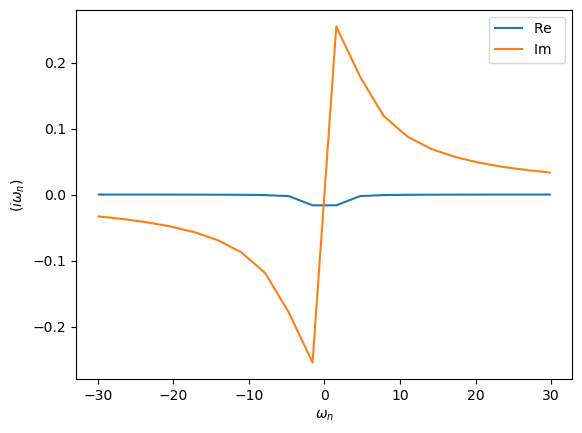

In [22]:
oplot(G_int1['0000'])

In [23]:
div_diff = HDFArchive("dimer_chi3_div_diff.h5", 'w')

for x, y, z, w in product(range(2),repeat=4):
    div_diff["G_int1"] = G_int1

# Reference 3 Point Function Dimer

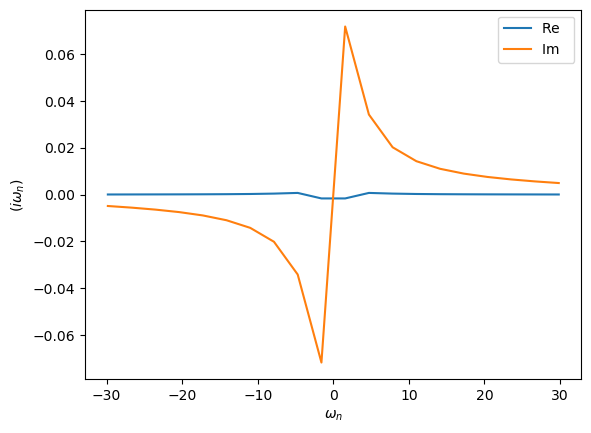

In [42]:
ref = HDFArchive("dimer_chi3.ref.h5", 'r')
G_iw = ref["chi3_ph_AABB"]['up','up'][1,1,1,0]

G_ref = Gf(mesh = fiw_mesh, target_shape = [])
G_ref.zero()

for iw2 in fiw_mesh:
    for iw1 in biw_mesh:
        G_ref[iw2] += G_iw[iw1,iw2]

oplot(G_ref)

In [30]:
ref["chi3_ph_AABB"]

Green's Function chi3_ph_AABB composed of 4 2-index blocks: 
 Greens Function chi3_ph_AABB_('up', 'up') with mesh Imaginary Freq Mesh with beta = 2, statistic = Boson, n_iw = 10, positive_only = false, Imaginary Freq Mesh with beta = 2, statistic = Fermion, n_iw = 10, positive_only = false and target_shape (2, 2, 2, 2): 
 
 Greens Function chi3_ph_AABB_('up', 'dn') with mesh Imaginary Freq Mesh with beta = 2, statistic = Boson, n_iw = 10, positive_only = false, Imaginary Freq Mesh with beta = 2, statistic = Fermion, n_iw = 10, positive_only = false and target_shape (2, 2, 2, 2): 
 
 Greens Function chi3_ph_AABB_('dn', 'up') with mesh Imaginary Freq Mesh with beta = 2, statistic = Boson, n_iw = 10, positive_only = false, Imaginary Freq Mesh with beta = 2, statistic = Fermion, n_iw = 10, positive_only = false and target_shape (2, 2, 2, 2): 
 
 Greens Function chi3_ph_AABB_('dn', 'dn') with mesh Imaginary Freq Mesh with beta = 2, statistic = Boson, n_iw = 10, positive_only = false, Imagin

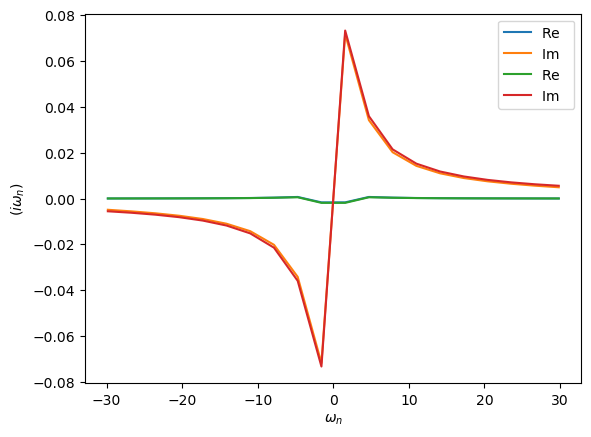

In [46]:

oplot(G_ref )
oplot(G_int1['1110'])


# 4 Point Function

In [26]:
%%time

ops = [(c_dag('up', 0), 'Fermion'),
       (c('up',0), 'Fermion'),
       (c('up', 0), 'Fermion'),
       (c_dag('up', 0), 'Fermion')]

corr = FourPtCorr(ops = ops, hamiltonian = (ad, eigensys))

G = corr.G_div_diff_iw(beta = beta, n_iw = [5,5,5])

start numerical calculations
CPU times: user 1min 5s, sys: 174 ms, total: 1min 5s
Wall time: 1min 5s


In [55]:
%%time

ops = [(c_dag('up', 0), 'Fermion'),
       (c('up',0), 'Fermion'),
       (c('up', 0), 'Fermion'),
       (c_dag('up', 0), 'Fermion')]

corr = FourPtCorr_v2(ops = ops, hamiltonian = (ad, eigensys))

G = corr.G_div_diff_iw(beta = beta, n_iw = [5,5,5])

start numerical calculations
CPU times: user 17.1 s, sys: 41 ms, total: 17.2 s
Wall time: 17.3 s
